In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

CLEANED_PATH = r"D:\Projects\End-to-end projects\17. SKU Proliferation & Rationalization\Data\Cleaned"
OUTPUT_PATH  = r"D:\Projects\End-to-end projects\17. SKU Proliferation & Rationalization\Outputs"

import os
os.makedirs(OUTPUT_PATH, exist_ok=True)

# Load
sku_master  = pd.read_csv(f"{CLEANED_PATH}/sku_master_clean.csv", parse_dates=["launch_date"])
sales       = pd.read_csv(f"{CLEANED_PATH}/sales_clean.csv",      parse_dates=["order_date"])
sku_ops     = pd.read_csv(f"{CLEANED_PATH}/sku_ops_clean.csv")
cfp         = pd.read_csv(f"{CLEANED_PATH}/customer_first_purchase_clean.csv")

sales["year_month"] = pd.to_datetime(sales["order_date"]).dt.to_period("M")

print("Cleaned data loaded ✓")
print(f"Sales: {sales.shape} | SKUs: {sku_master.shape} | Ops: {sku_ops.shape} | CFP: {cfp.shape}")

Cleaned data loaded ✓
Sales: (78191, 11) | SKUs: (280, 11) | Ops: (280, 7) | CFP: (33881, 8)


In [2]:
# --- SKU-level revenue summary ---
sku_rev = (
    sales
    .groupby("sku_id")
    .agg(
        total_revenue  = ("revenue", "sum"),
        total_units    = ("units_sold", "sum"),
        total_orders   = ("order_id", "count"),
        avg_sell_price = ("selling_price", "mean"),
        avg_discount   = ("discount_pct", "mean")
    )
    .reset_index()
    .sort_values("total_revenue", ascending=False)
)

# Cumulative revenue %
sku_rev["revenue_rank"]       = range(1, len(sku_rev) + 1)
sku_rev["cumulative_rev_pct"] = (sku_rev["total_revenue"].cumsum() / sku_rev["total_revenue"].sum() * 100).round(2)
sku_rev["revenue_share_pct"]  = (sku_rev["total_revenue"] / sku_rev["total_revenue"].sum() * 100).round(3)

# How many SKUs drive 50%, 80%, 95% of revenue?
for threshold in [50, 80, 95]:
    n = (sku_rev["cumulative_rev_pct"] <= threshold).sum()
    print(f"SKUs driving {threshold}% of revenue: {n} out of {len(sku_rev)} ({n/len(sku_rev)*100:.1f}%)")

print(f"\nBottom 50% of SKUs contribute: {sku_rev.tail(len(sku_rev)//2)['revenue_share_pct'].sum():.1f}% of revenue")

SKUs driving 50% of revenue: 22 out of 258 (8.5%)
SKUs driving 80% of revenue: 60 out of 258 (23.3%)
SKUs driving 95% of revenue: 159 out of 258 (61.6%)

Bottom 50% of SKUs contribute: 8.2% of revenue


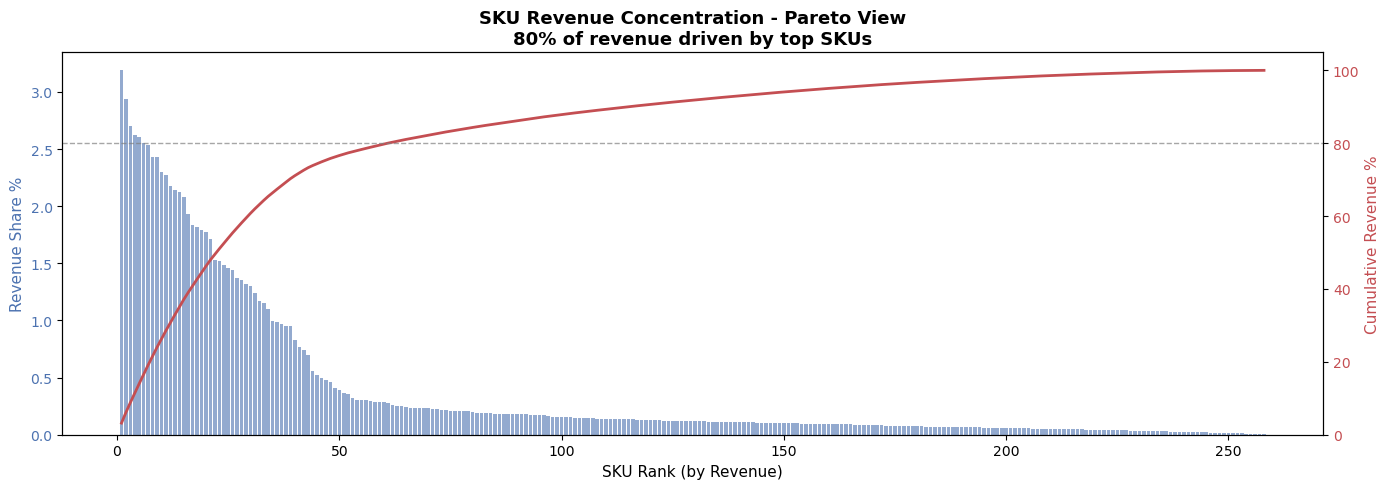

Chart saved ✓


In [4]:
fig, ax1 = plt.subplots(figsize=(14, 5))

# Bar: individual SKU revenue share
ax1.bar(sku_rev["revenue_rank"], sku_rev["revenue_share_pct"],
        color="#4C72B0", alpha=0.6, label="SKU Revenue Share %")
ax1.set_xlabel("SKU Rank (by Revenue)", fontsize=11)
ax1.set_ylabel("Revenue Share %", fontsize=11, color="#4C72B0")
ax1.tick_params(axis="y", labelcolor="#4C72B0")

# Line: cumulative %
ax2 = ax1.twinx()
ax2.plot(sku_rev["revenue_rank"], sku_rev["cumulative_rev_pct"],
         color="#C44E52", linewidth=2, label="Cumulative Revenue %")
ax2.axhline(80, color="gray", linestyle="--", linewidth=1, alpha=0.7)
ax2.set_ylabel("Cumulative Revenue %", fontsize=11, color="#C44E52")
ax2.tick_params(axis="y", labelcolor="#C44E52")
ax2.set_ylim(0, 105)

plt.title("SKU Revenue Concentration - Pareto View\n80% of revenue driven by top SKUs",
          fontsize=13, fontweight="bold")
fig.tight_layout()
plt.savefig(f"{OUTPUT_PATH}/01_pareto_revenue.png", dpi=150)
plt.show()
print("Chart saved ✓")

In [5]:
# Merge category info
sku_rev_cat = sku_rev.merge(sku_master[["sku_id", "category", "subcategory",
                                         "gross_margin_pct", "sku_age_months"]], on="sku_id")

cat_summary = (
    sku_rev_cat
    .groupby("category")
    .agg(
        sku_count       = ("sku_id", "count"),
        total_revenue   = ("total_revenue", "sum"),
        avg_margin      = ("gross_margin_pct", "mean"),
        avg_discount    = ("avg_discount", "mean")
    )
    .reset_index()
    .sort_values("total_revenue", ascending=False)
)

cat_summary["revenue_share_pct"] = (cat_summary["total_revenue"] / cat_summary["total_revenue"].sum() * 100).round(1)
cat_summary["avg_discount"]      = (cat_summary["avg_discount"] * 100).round(1)
cat_summary["avg_margin"]        = cat_summary["avg_margin"].round(1)

print("=== CATEGORY PERFORMANCE SUMMARY ===\n")
print(cat_summary[["category", "sku_count", "revenue_share_pct",
                    "avg_margin", "avg_discount"]].to_string(index=False))

=== CATEGORY PERFORMANCE SUMMARY ===

 category  sku_count  revenue_share_pct  avg_margin  avg_discount
 Haircare         42               63.9        63.0          11.6
 Skincare         46               17.3        61.6          11.7
Baby Care         42                5.5        63.0          11.8
Oral Care         44                4.8        62.1          11.9
Nutrition         41                4.4        63.2          12.1
Body Care         43                4.0        60.1          11.0


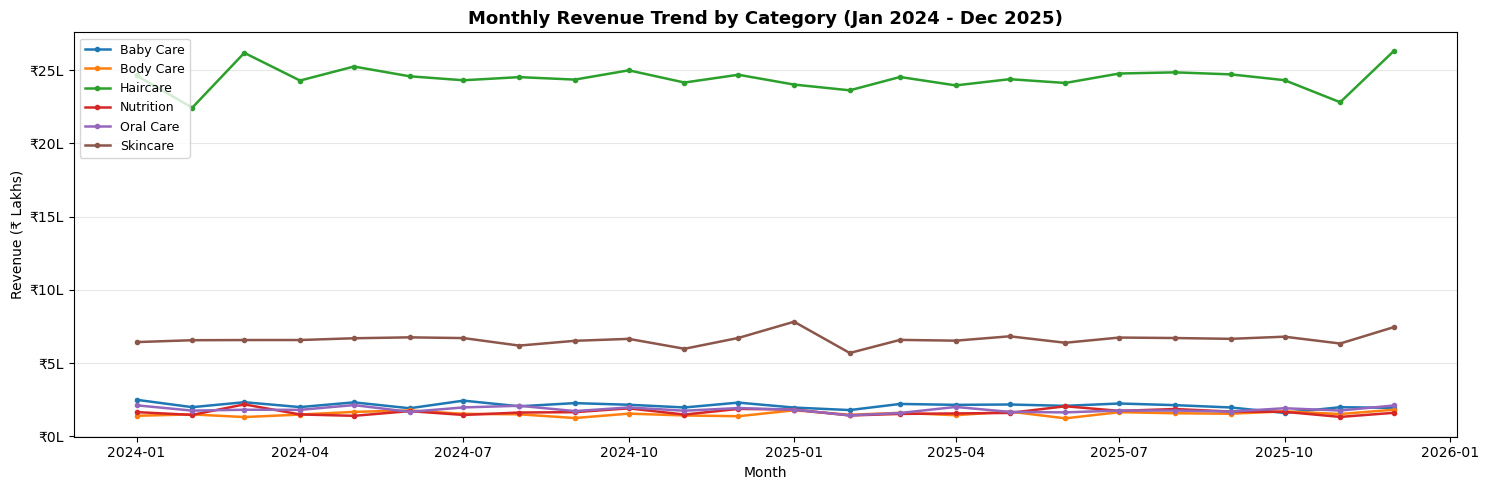

Chart saved ✓


In [6]:
# Monthly revenue per category
sales_cat = sales.merge(sku_master[["sku_id", "category"]], on="sku_id")
monthly_cat = (
    sales_cat
    .groupby(["year_month", "category"])["revenue"]
    .sum()
    .reset_index()
)
monthly_cat["year_month"] = monthly_cat["year_month"].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(15, 5))
for cat in monthly_cat["category"].unique():
    data = monthly_cat[monthly_cat["category"] == cat]
    ax.plot(data["year_month"], data["revenue"], marker="o", markersize=3,
            linewidth=1.8, label=cat)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"₹{x/1e5:.0f}L"))
ax.set_title("Monthly Revenue Trend by Category (Jan 2024 - Dec 2025)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue (₹ Lakhs)")
ax.legend(loc="upper left", fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_PATH}/02_monthly_trend_by_category.png", dpi=150)
plt.show()
print("Chart saved ✓")

In [7]:
# Compare H1 2024 vs H2 2025 revenue per SKU
# Why these two periods: earliest 6 months vs latest 6 months = clearest trend signal

h1_2024 = sales[sales["order_date"].between("2024-01-01", "2024-06-30")]
h2_2025 = sales[sales["order_date"].between("2025-07-01", "2025-12-31")]

rev_h1 = h1_2024.groupby("sku_id")["revenue"].sum().reset_index().rename(columns={"revenue": "rev_h1_2024"})
rev_h2 = h2_2025.groupby("sku_id")["revenue"].sum().reset_index().rename(columns={"revenue": "rev_h2_2025"})

velocity = rev_h1.merge(rev_h2, on="sku_id", how="outer").fillna(0)
velocity["growth_pct"] = (
    (velocity["rev_h2_2025"] - velocity["rev_h1_2024"]) /
    velocity["rev_h1_2024"].replace(0, np.nan) * 100
).round(1)

# Classify velocity
def classify_velocity(row):
    if row["rev_h1_2024"] == 0 and row["rev_h2_2025"] > 0:
        return "New/Emerging"
    elif row["rev_h2_2025"] == 0:
        return "Dead"
    elif row["growth_pct"] >= 20:
        return "Growing"
    elif row["growth_pct"] <= -20:
        return "Declining"
    else:
        return "Stable"

velocity["velocity_tag"] = velocity.apply(classify_velocity, axis=1)

print("=== SKU VELOCITY DISTRIBUTION ===\n")
v_summary = velocity["velocity_tag"].value_counts().reset_index()
v_summary.columns = ["Velocity Tag", "SKU Count"]
v_summary["% of SKUs"] = (v_summary["SKU Count"] / len(velocity) * 100).round(1)
print(v_summary.to_string(index=False))

=== SKU VELOCITY DISTRIBUTION ===

Velocity Tag  SKU Count  % of SKUs
      Stable        134       51.9
     Growing         66       25.6
   Declining         58       22.5


In [8]:
# Which SKUs are most common as a customer's first purchase?
gateway = (
    cfp
    .groupby("first_sku_id")
    .agg(
        times_as_first_purchase = ("customer_id", "count"),
        avg_ltv_90d             = ("ltv_90d", "mean"),
        repeat_rate             = ("is_repeat_customer", "mean")
    )
    .reset_index()
    .rename(columns={"first_sku_id": "sku_id"})
    .sort_values("times_as_first_purchase", ascending=False)
)

gateway["avg_ltv_90d"]  = gateway["avg_ltv_90d"].round(0)
gateway["repeat_rate"]  = (gateway["repeat_rate"] * 100).round(1)

# Merge with revenue to find low-revenue but high-gateway SKUs
gateway = gateway.merge(sku_rev[["sku_id", "total_revenue", "revenue_share_pct"]], on="sku_id")
gateway = gateway.merge(sku_master[["sku_id", "sku_name", "category"]], on="sku_id")

# Flag Gateway SKUs: high first-purchase count but low revenue share
# These are the dangerous ones to kill
gateway["gateway_flag"] = (
    (gateway["times_as_first_purchase"] >= gateway["times_as_first_purchase"].quantile(0.75)) &
    (gateway["revenue_share_pct"] < 0.5)  # Less than 0.5% revenue share
)

print("=== TOP 15 GATEWAY SKUs ===\n")
print(gateway.head(15)[["sku_id", "category", "times_as_first_purchase",
                          "repeat_rate", "avg_ltv_90d",
                          "revenue_share_pct", "gateway_flag"]].to_string(index=False))

print(f"\nSKUs flagged as Gateway (low revenue, high acquisition role): {gateway['gateway_flag'].sum()}")

=== TOP 15 GATEWAY SKUs ===

 sku_id category  times_as_first_purchase  repeat_rate  avg_ltv_90d  revenue_share_pct  gateway_flag
SKU0038 Haircare                      689         72.1       1069.0              1.369         False
SKU0014 Haircare                      681         73.7       1822.0              2.536         False
SKU0005 Haircare                      679         71.3        857.0              0.971         False
SKU0013 Haircare                      658         72.3       1344.0              1.713         False
SKU0011 Haircare                      647         73.1       1636.0              2.178         False
SKU0012 Haircare                      643         73.6       1921.0              2.429         False
SKU0032 Haircare                      640         69.7       1220.0              1.519         False
SKU0040 Haircare                      639         75.4       1999.0              2.623         False
SKU0031 Haircare                      636         74.5        

In [9]:
print("=== EXPLORATORY ANALYSIS SUMMARY ===\n")

# Revenue concentration
top_10_pct  = int(len(sku_rev) * 0.10)
top_10_rev  = sku_rev.head(top_10_pct)["revenue_share_pct"].sum()

print(f"[Revenue Concentration]")
print(f"  Top 10% SKUs drive  : {top_10_rev:.1f}% of revenue")
print(f"  Active SKUs in sales: {len(sku_rev)}")

# Velocity
print(f"\n[SKU Velocity]")
for tag in ["Growing", "Stable", "Declining", "Dead", "New/Emerging"]:
    n = (velocity["velocity_tag"] == tag).sum()
    print(f"  {tag:<15}: {n} SKUs")

# Gateway
print(f"\n[Gateway SKUs]")
print(f"  Low-revenue gateway SKUs : {gateway['gateway_flag'].sum()}")
print(f"  Avg LTV from gateway SKUs: ₹{gateway[gateway['gateway_flag']]['avg_ltv_90d'].mean():,.0f}")
print(f"  Avg repeat rate (gateway): {gateway[gateway['gateway_flag']]['repeat_rate'].mean():.1f}%")

print("\nEDA complete. Ready for Step 6: Core Analysis & Modeling ✓")

=== EXPLORATORY ANALYSIS SUMMARY ===

[Revenue Concentration]
  Top 10% SKUs drive  : 54.0% of revenue
  Active SKUs in sales: 258

[SKU Velocity]
  Growing        : 66 SKUs
  Stable         : 134 SKUs
  Declining      : 58 SKUs
  Dead           : 0 SKUs
  New/Emerging   : 0 SKUs

[Gateway SKUs]
  Low-revenue gateway SKUs : 21
  Avg LTV from gateway SKUs: ₹1,283
  Avg repeat rate (gateway): 74.3%

EDA complete. Ready for Step 6: Core Analysis & Modeling ✓
